# 第7章 读懂 Roofline 图

得到时间以后，优先研究数据访问还是计算？我们从向量加法数出计算量、读写量，再把本次 GPU 测量画成一个点。参考线也从当前设备测量，不把其他显卡的固定峰值带进来。

前置：[第6章](../chapter6/chapter6.ipynb)。对应[正文](../../../docs/part1-profiling/chapter7/index.md)。


## 7.1 一次加法包含多少工作

一个 FP32 输出对应一次加法、两次读取和一次写入：$F=N$ FLOP，$Q=12N$ Byte，所以 $AI=F/Q=1/12$ FLOP/Byte。长度抵消，规模增加不会改变算法算术强度。


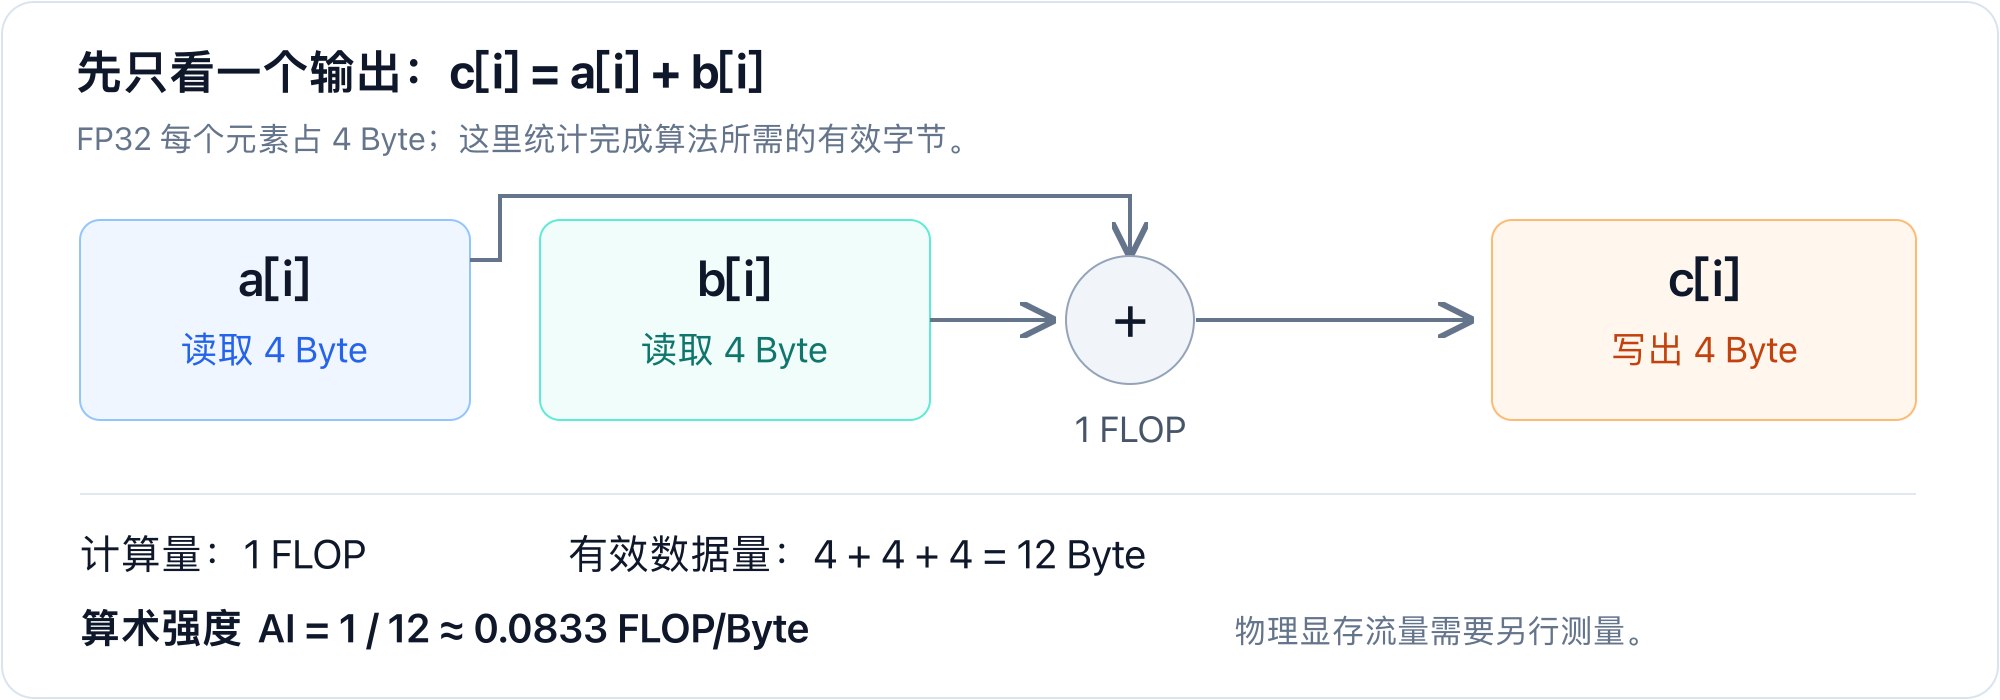

*先按算法计算 F 与 Q，再讨论硬件参考。*


In [ ]:
%run ../../common/bootstrap.py

import torch
import hello_gpu as gpu
from hello_gpu import learning, profiling
%load_ext hello_gpu
cfg = gpu.settings()
env = gpu.environment()
env


In [ ]:
N = cfg['n']
F, Q = N, 12*N
AI = F/Q
print({'FLOP':F,'logical_bytes':Q,'AI':AI})


## 7.2 为什么图上的线像屋顶

参考带宽对应斜线 $P=BW\times AI$；参考计算吞吐对应水平线；两条线取小值形成屋顶。这里测 `copy_` 和 FP32 矩阵乘来建立**工作负载参考线**，它们不是硬件峰值，不是其他 kernel 不可越过的物理上限。

可在 config.toml 的 roofline 中提供 bandwidth_gbs、compute_tflops 和来源；默认零表示本次运行测量。矩阵大小也可以调整。


In [ ]:
from hello_gpu.config import configuration
roof_cfg = configuration().get('roofline', {})
references = learning.roofline_references(n=N, matrix_size=roof_cfg.get('matrix_size',512),
                                         warmup=cfg['warmup'], repeat=cfg['repeat'])
if roof_cfg.get('bandwidth_gbs',0)>0 and roof_cfg.get('compute_tflops',0)>0:
    assert roof_cfg.get('source'), '手动参考值必须说明来源'
    references.update({key:roof_cfg[key] for key in ('bandwidth_gbs','compute_tflops','source')})
print({k:references[k] for k in ('bandwidth_gbs','compute_tflops','source')})


## 7.3 把一次测量变成一个点

横坐标采用算法 AI，纵坐标是 $F/t$。继续使用相同的计时边界：预分配输出，固定随机输入，先校验，稳态 event 计时。


In [ ]:
%%hip vector_add --entry vector_add
__global__ void vector_add(const float* a, const float* b, float* c, int n) {
    int64_t i = static_cast<int64_t>(blockIdx.x) * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}


In [ ]:
a, b = learning.inputs(N, seed=cfg['seed'])
out = torch.empty_like(a)
run = vector_add.prepare(a, b, block=cfg['block'], out=out)
run()
torch.testing.assert_close(out, a + b)


In [ ]:
table = learning.compare({'HIP Vector Add':run}, reference=a+b,
                         outputs={'HIP Vector Add':out},warmup=cfg['warmup'],repeat=cfg['repeat'])
table['algorithmic_GFLOP_s'] = F/table['median_ms']/1e6
table['algorithmic_GB_s'] = Q/table['median_ms']/1e6
table


## 7.4 生成图，并沿着坐标读一遍

实测点与参考线来自同一次环境。若一个小数组工作点低于斜线，只能先提出假设；启动成本、缓存、访问顺序和 CPU 提交节奏都可能参与。不能凭点的位置宣布唯一瓶颈。


In [ ]:
learning.plot_roofline(table,flops=F,bytes_moved=Q,references=references)


## 7.5 从读图走到下一轮实验

扩大 N 保持 AI 不变，却可能减少启动成本在总时间中的占比；改算法以复用数据，才可能改变逻辑读写量。先选一个问题，固定其他条件再测。


In [ ]:
print('当前输入工作量：',N,'元素；逻辑 AI：',AI,'FLOP/Byte')


## 7.6 练习

把 N 改成四倍，从 7.1 开始运行，检查新点是否仍在同一个横坐标。再调整 matrix_size，记录参考线为何变化。写下你选的是实测工作负载参考还是官方理论参数，二者不能混称。

保存所有当前样本、kernel 源码和参考条件，方便下一轮核对。


In [ ]:
learning.save_table('part1-profiling/chapter7',table,config={**cfg,'n':N,'references':references},kernels=[vector_add])


## 本章小结

Roofline 把逻辑计算量、数据量和时间放在统一坐标中。参考线用于提出下一步问题；证明瓶颈还需要受控修改和针对性诊断。

## 延伸阅读

- [第8章 notebook](../../part2-kernels/chapter8/chapter8.ipynb)
- [Roofline 原论文](https://doi.org/10.1145/1498765.1498785)
